In [ ]:
# 1) IMPORTS
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import randint, uniform, loguniform
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    KFold,
    ParameterSampler,
    StratifiedKFold
)
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    RobustScaler,
    StandardScaler,
    OrdinalEncoder
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.base import clone
from copy import deepcopy

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)

In [ ]:
# 2) LOAD DATA
DATA_PATH = r"Final_Used_Cars_Egypt.csv"
SAVE_DIR = r"models"
os.makedirs(SAVE_DIR, exist_ok=True)

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Shape: (25223, 25)

Columns:
['Brand', 'Model', 'Trim', 'Year', 'Price', 'Mileage', 'Color', 'Fuel Type', 'Body Shape', 'Transmission', 'Engine', 'Engine Capacity', 'Cylinder Count', 'Turbo Count', 'HP', 'Drivetrain', 'car_age', 'miles_per_year', 'Brand_Tier', 'Image Paths', 'Condition', 'Condition_Score', 'model_average_price', 'model_min_price', 'model_max_price']


In [ ]:
# 3) KEEP ONLY NEEDED COLUMNS
target_col = "Price"

selected_features = [
    "Brand",
    "Model",
    "Trim",
    "Year",
    "Mileage",
    "Color",
    "Fuel Type",
    "Body Shape",
    "Transmission",
    "Engine",
    "Engine Capacity",
    "Cylinder Count",
    "Turbo Count",
    "HP",
    "Drivetrain",
    "car_age",
    "miles_per_year",
    "Brand_Tier",
    "Condition",
    "Condition_Score",
    "model_average_price",
]

drop_columns = [
    "Image Paths",
    "model_min_price",
    "model_max_price",
]

required_cols = selected_features + [target_col]
df = df[required_cols].copy()

print("Final shape after selecting needed columns:", df.shape)

Final shape after selecting needed columns: (25223, 22)


In [ ]:
# 4) BASIC DATA ANALYSIS
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum().sort_values(ascending=False))

print("\nDescriptive Stats:")
print(df.describe(include="all").T)

print("\nTarget Summary:")
print(df[target_col].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]))


Data Types:
Brand                      str
Model                      str
Trim                       str
Year                     int64
Mileage                  int64
Color                      str
Fuel Type                  str
Body Shape                 str
Transmission               str
Engine                     str
Engine Capacity          int64
Cylinder Count           int64
Turbo Count              int64
HP                       int64
Drivetrain                 str
car_age                  int64
miles_per_year         float64
Brand_Tier               int64
Condition                  str
Condition_Score        float64
model_average_price    float64
Price                    int64
dtype: object

Missing Values:
Brand                  0
Model                  0
Trim                   0
Year                   0
Mileage                0
Color                  0
Fuel Type              0
Body Shape             0
Transmission           0
Engine                 0
Engine Capacity        0

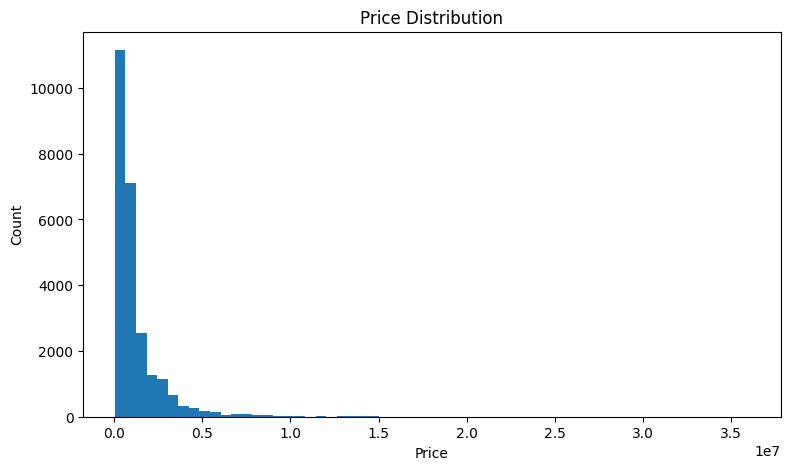

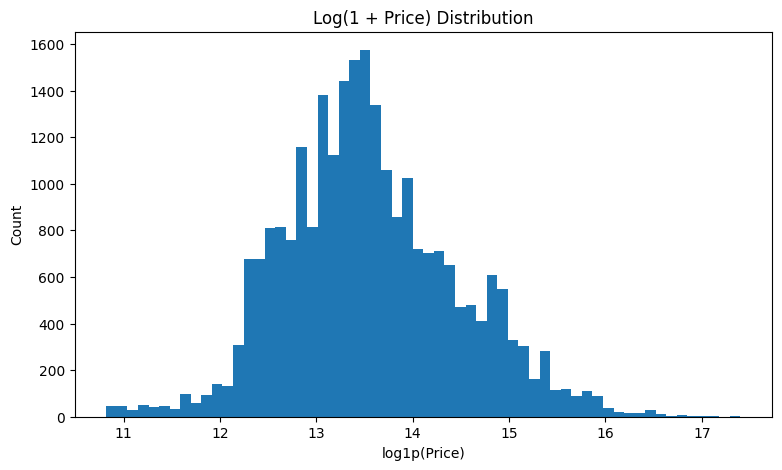

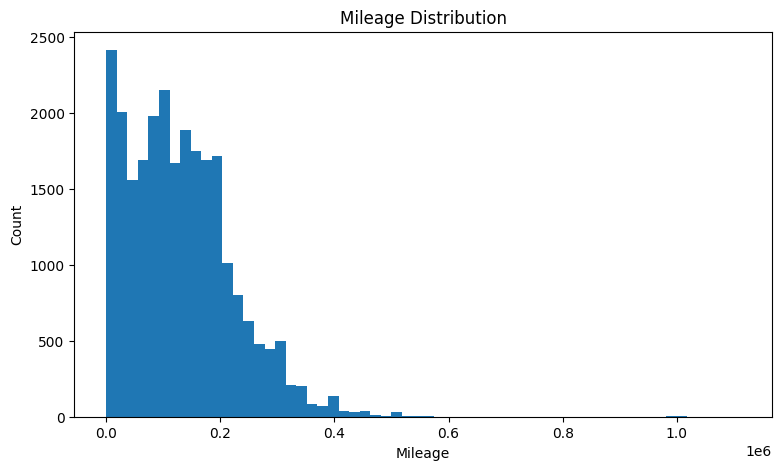

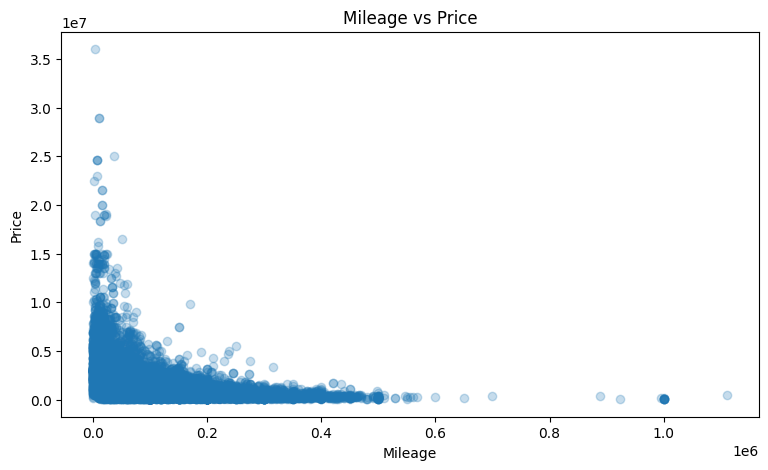

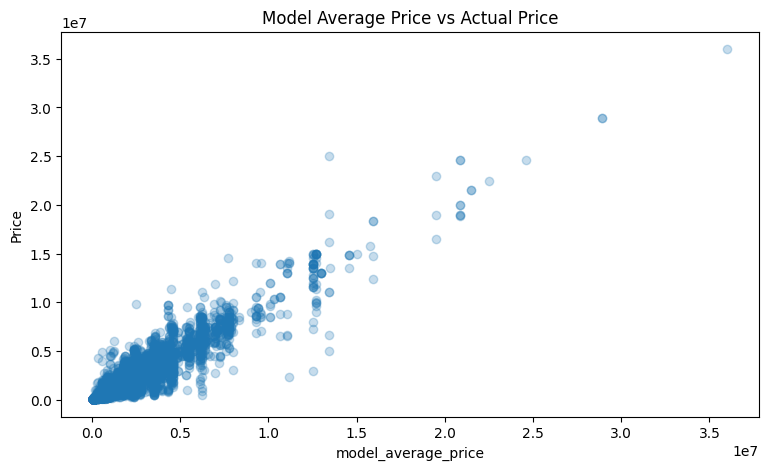

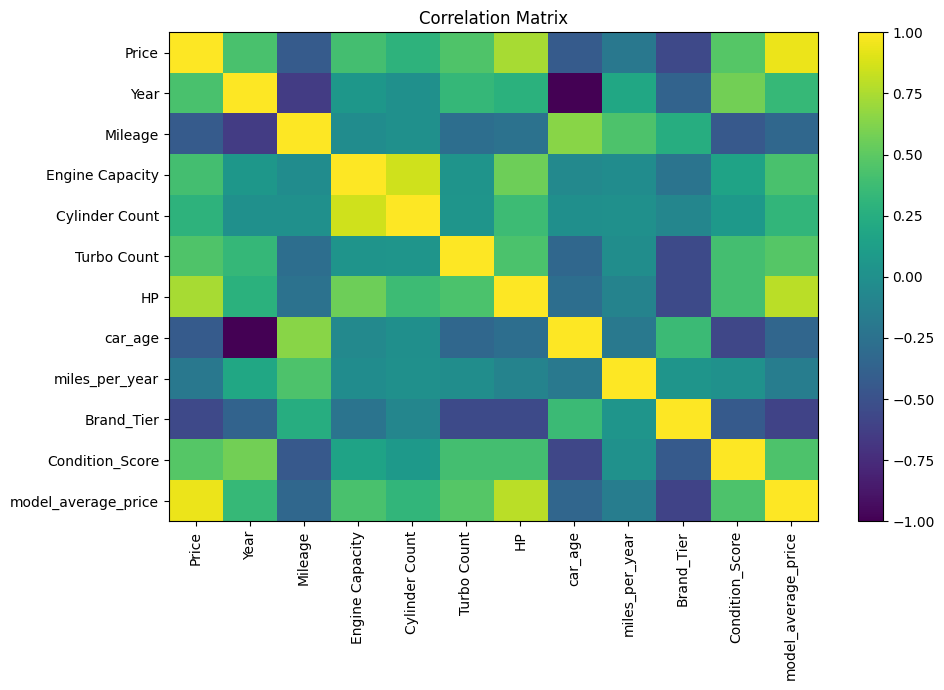

In [ ]:
# 5) VISUAL ANALYSIS
plt.figure(figsize=(9, 5))
plt.hist(df["Price"], bins=60)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(np.log1p(df["Price"]), bins=60)
plt.title("Log(1 + Price) Distribution")
plt.xlabel("log1p(Price)")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(9, 5))
plt.hist(df["Mileage"], bins=60)
plt.title("Mileage Distribution")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(df["Mileage"], df["Price"], alpha=0.25)
plt.title("Mileage vs Price")
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.show()

plt.figure(figsize=(9, 5))
plt.scatter(df["model_average_price"], df["Price"], alpha=0.25)
plt.title("Model Average Price vs Actual Price")
plt.xlabel("model_average_price")
plt.ylabel("Price")
plt.show()

numeric_cols_for_corr = [
    "Price",
    "Year",
    "Mileage",
    "Engine Capacity",
    "Cylinder Count",
    "Turbo Count",
    "HP",
    "car_age",
    "miles_per_year",
    "Brand_Tier",
    "Condition_Score",
    "model_average_price",
]

corr = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(10, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.colorbar()
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [ ]:
# 6) OUTLIER HANDLING
df_model = df.copy()

numeric_features_base = [
    "Year",
    "Mileage",
    "Engine Capacity",
    "Cylinder Count",
    "Turbo Count",
    "HP",
    "car_age",
    "miles_per_year",
    "Brand_Tier",
    "Condition_Score",
    "model_average_price",
]

for col in numeric_features_base:
    lower = df_model[col].quantile(0.01)
    upper = df_model[col].quantile(0.99)
    df_model[col] = df_model[col].clip(lower, upper)

In [ ]:
# 7) TRAIN / TEST SPLIT
X = df_model[selected_features].copy()
y = df_model[target_col].copy()

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = [c for c in X.columns if c not in categorical_features]

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

# stratify regression target using quantile bins
price_bins = pd.qcut(y, q=10, duplicates="drop")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=price_bins
)

print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

Categorical features: ['Brand', 'Model', 'Trim', 'Color', 'Fuel Type', 'Body Shape', 'Transmission', 'Engine', 'Drivetrain', 'Condition']
Numeric features: ['Year', 'Mileage', 'Engine Capacity', 'Cylinder Count', 'Turbo Count', 'HP', 'car_age', 'miles_per_year', 'Brand_Tier', 'Condition_Score', 'model_average_price']
Train shape: (20178, 21) (20178,)
Test shape: (5045, 21) (5045,)


In [ ]:
# 8) PREPROCESSORS
# Tree models
tree_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

tree_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", min_frequency=20))
])

tree_preprocessor = ColumnTransformer(
    transformers=[
        ("num", tree_numeric_transformer, numeric_features),
        ("cat", tree_categorical_transformer, categorical_features),
    ]
)


In [ ]:
# 9) EVALUATION FUNCTION
def evaluate_model(name, model, X_test, y_test):
    preds = model.predict(X_test)
    preds = np.maximum(preds, 0)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    print(f"\n{name} Results")
    print("-" * 40)
    print(f"RMSE: {rmse:,.2f}")
    print(f"MAE : {mae:,.2f}")
    print(f"R2  : {r2:.4f}")

    return {
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    }

In [ ]:
# 10) MODELS + TUNING SETUP
cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "XGBoost": TransformedTargetRegressor(
        regressor=Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", XGBRegressor(
                objective="reg:squarederror",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            ))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    ),

    "LightGBM": TransformedTargetRegressor(
        regressor=Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", LGBMRegressor(
                random_state=42,
                n_jobs=-1,
                verbose=-1
            ))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    ),

    "RandomForest": TransformedTargetRegressor(
        regressor=Pipeline([
            ("preprocessor", tree_preprocessor),
            ("model", RandomForestRegressor(
                random_state=42,
                n_jobs=-1
            ))
        ]),
        func=np.log1p,
        inverse_func=np.expm1
    )
}

param_distributions = {
    "XGBoost": {
        "regressor__model__n_estimators": randint(600, 1800),
        "regressor__model__learning_rate": uniform(0.01, 0.06),
        "regressor__model__max_depth": randint(3, 9),
        "regressor__model__min_child_weight": randint(1, 10),
        "regressor__model__subsample": uniform(0.75, 0.25),
        "regressor__model__colsample_bytree": uniform(0.75, 0.25),
        "regressor__model__gamma": uniform(0.0, 2.0),
        "regressor__model__reg_alpha": uniform(0.0, 1.5),
        "regressor__model__reg_lambda": uniform(0.5, 4.0),
    },

    "LightGBM": {
        "regressor__model__n_estimators": randint(600, 1800),
        "regressor__model__learning_rate": uniform(0.01, 0.06),
        "regressor__model__num_leaves": randint(31, 200),
        "regressor__model__max_depth": randint(4, 14),
        "regressor__model__min_child_samples": randint(10, 80),
        "regressor__model__subsample": uniform(0.75, 0.25),
        "regressor__model__colsample_bytree": uniform(0.75, 0.25),
        "regressor__model__reg_alpha": uniform(0.0, 1.5),
        "regressor__model__reg_lambda": uniform(0.5, 4.0),
    },

    "RandomForest": {
        "regressor__model__n_estimators": randint(500, 1600),
        "regressor__model__max_depth": [None, 20, 30, 40, 50, 60],
        "regressor__model__min_samples_split": randint(2, 12),
        "regressor__model__min_samples_leaf": randint(1, 5),
        "regressor__model__max_features": ["sqrt", "log2", 0.4, 0.6, 0.8],
        "regressor__model__bootstrap": [True],
    }
}

In [ ]:
# 11) TRAIN + TUNE NON-CATBOOST MODELS
best_models = {}
results = []
search_objects = {}

for model_name, model in models.items():
    print(f"\nTraining {model_name}...")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_distributions[model_name],
        n_iter=35,
        scoring="neg_root_mean_squared_error",
        cv=cv,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    best_models[model_name] = best_model
    search_objects[model_name] = search

    print(f"Best Params for {model_name}:")
    print(search.best_params_)

    result = evaluate_model(model_name, best_model, X_test, y_test)
    results.append(result)

    joblib.dump(best_model, os.path.join(SAVE_DIR, f"{model_name}_best.pkl"))


Training XGBoost...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Params for XGBoost:
{'regressor__model__colsample_bytree': np.float64(0.8626248129923857), 'regressor__model__gamma': np.float64(0.026529922319733057), 'regressor__model__learning_rate': np.float64(0.06653210534109116), 'regressor__model__max_depth': 8, 'regressor__model__min_child_weight': 2, 'regressor__model__n_estimators': 1376, 'regressor__model__reg_alpha': np.float64(0.02394937833032129), 'regressor__model__reg_lambda': np.float64(1.423575302488596), 'regressor__model__subsample': np.float64(0.8102563665065029)}

XGBoost Results
----------------------------------------
RMSE: 380,755.14
MAE : 128,635.85
R2  : 0.9401

Training LightGBM...
Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best Params for LightGBM:
{'regressor__model__colsample_bytree': np.float64(0.8135409122674346), 'regressor__model__learning_rate': np.float64(0.027717435305136325), 'regressor__model__max_depth': 1

In [ ]:
# 12) CATBOOST
X_train_cb = X_train[selected_features].copy()
X_test_cb = X_test[selected_features].copy()

for col in categorical_features:
    X_train_cb[col] = X_train_cb[col].astype(str)
    X_test_cb[col] = X_test_cb[col].astype(str)

cat_feature_indices = [X_train_cb.columns.get_loc(col) for col in categorical_features]

cb_param_dist = {
    "depth": randint(4, 11),
    "learning_rate": uniform(0.01, 0.07),
    "iterations": randint(700, 1800),
    "l2_leaf_reg": uniform(1, 10),
    "bagging_temperature": uniform(0, 1),
    "random_strength": uniform(0, 3),
}

best_cb_cv_score = np.inf
best_cb_model = None
best_cb_params = None

for i, params in enumerate(ParameterSampler(cb_param_dist, n_iter=35, random_state=42), start=1):
    print(f"CatBoost trial {i}/35")

    fold_rmses = []

    for train_idx, valid_idx in cv.split(X_train_cb):
        X_tr = X_train_cb.iloc[train_idx]
        X_val = X_train_cb.iloc[valid_idx]
        y_tr = y_train.iloc[train_idx]
        y_val = y_train.iloc[valid_idx]

        current_model = CatBoostRegressor(
            **params,
            loss_function="RMSE",
            eval_metric="RMSE",
            random_seed=42,
            verbose=0
        )

        current_model.fit(
            X_tr,
            np.log1p(y_tr),
            cat_features=cat_feature_indices
        )

        pred_log = current_model.predict(X_val)
        preds = np.expm1(pred_log)
        preds = np.maximum(preds, 0)

        fold_rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmses.append(fold_rmse)

    mean_cv_rmse = np.mean(fold_rmses)

    if mean_cv_rmse < best_cb_cv_score:
        best_cb_cv_score = mean_cv_rmse
        best_cb_params = params

print("\nBest CatBoost Params:")
print(best_cb_params)
print("Best CatBoost CV RMSE:", best_cb_cv_score)

best_cb_model = CatBoostRegressor(
    **best_cb_params,
    loss_function="RMSE",
    eval_metric="RMSE",
    random_seed=42,
    verbose=0
)

best_cb_model.fit(
    X_train_cb,
    np.log1p(y_train),
    cat_features=cat_feature_indices
)

class CatBoostLogWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        preds = np.expm1(self.model.predict(X))
        return np.maximum(preds, 0)

catboost_wrapper = CatBoostLogWrapper(best_cb_model)
best_models["CatBoost"] = best_cb_model

cb_result = evaluate_model("CatBoost", catboost_wrapper, X_test_cb, y_test)
results.append(cb_result)

joblib.dump(best_cb_model, os.path.join(SAVE_DIR, "CatBoost_best.pkl"))

CatBoost trial 1/35
CatBoost trial 2/35
CatBoost trial 3/35
CatBoost trial 4/35
CatBoost trial 5/35
CatBoost trial 6/35
CatBoost trial 7/35
CatBoost trial 8/35
CatBoost trial 9/35
CatBoost trial 10/35
CatBoost trial 11/35
CatBoost trial 12/35
CatBoost trial 13/35
CatBoost trial 14/35
CatBoost trial 15/35
CatBoost trial 16/35
CatBoost trial 17/35
CatBoost trial 18/35
CatBoost trial 19/35
CatBoost trial 20/35
CatBoost trial 21/35
CatBoost trial 22/35
CatBoost trial 23/35
CatBoost trial 24/35
CatBoost trial 25/35
CatBoost trial 26/35
CatBoost trial 27/35
CatBoost trial 28/35
CatBoost trial 29/35
CatBoost trial 30/35
CatBoost trial 31/35
CatBoost trial 32/35
CatBoost trial 33/35
CatBoost trial 34/35
CatBoost trial 35/35

Best CatBoost Params:
{'bagging_temperature': np.float64(0.5296505783560065), 'depth': 5, 'iterations': 1596, 'l2_leaf_reg': np.float64(1.9310276780589921), 'learning_rate': np.float64(0.07280510305673288), 'random_strength': np.float64(2.7012541714899916)}
Best CatBoost C

['models\\CatBoost_best.pkl']

In [ ]:
# 13) RESULTS TABLE
results_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(results_df)

          Model           RMSE            MAE        R2
0      LightGBM  328781.942588  124515.476263  0.955330
1      CatBoost  337372.591495  131547.729385  0.952965
2  RandomForest  344638.475120  120508.487344  0.950917
3       XGBoost  380755.143577  128635.851562  0.940090


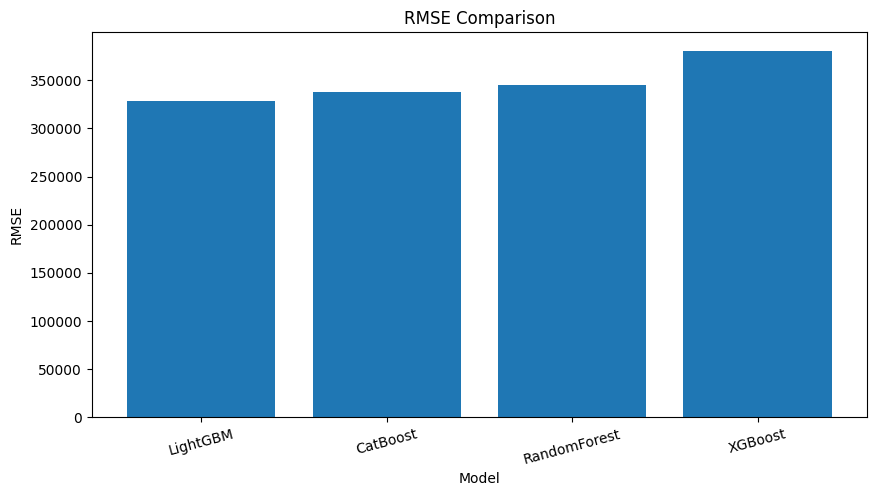

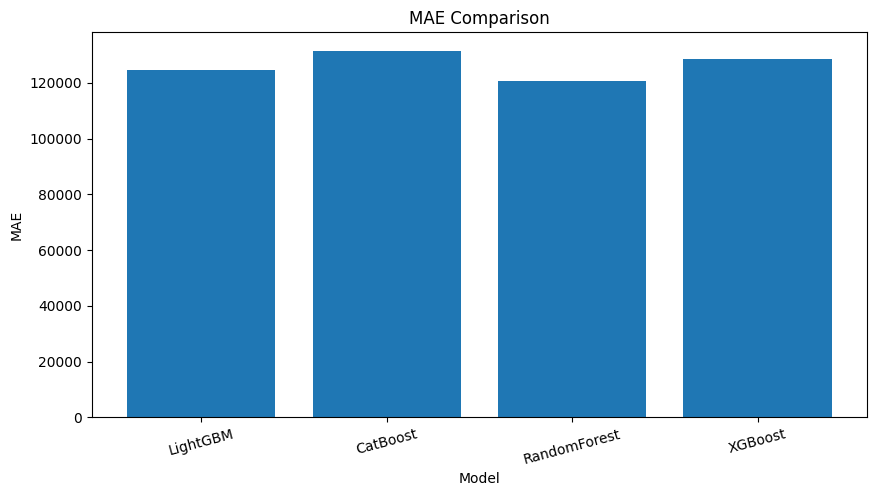

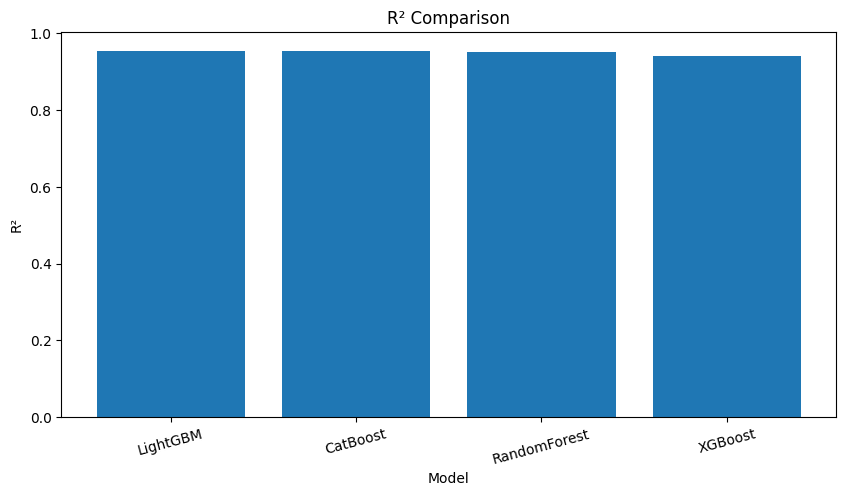

In [ ]:
# 14) FINAL COMPARISON PLOTS
plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["RMSE"])
plt.title("RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["MAE"])
plt.title("MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")
plt.xticks(rotation=15)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(results_df["Model"], results_df["R2"])
plt.title("R² Comparison")
plt.xlabel("Model")
plt.ylabel("R²")
plt.xticks(rotation=15)
plt.show()

Best model: LightGBM


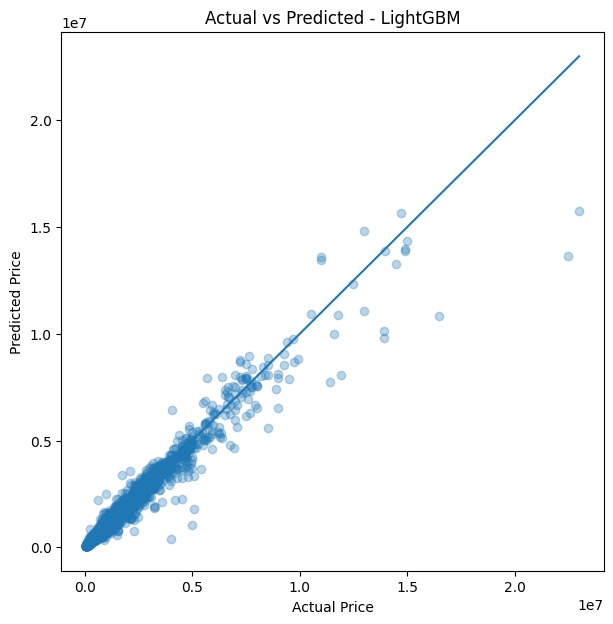

In [ ]:
# 15) BEST MODEL + PREDICTION PLOT
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

if best_model_name == "CatBoost":
    best_preds = np.maximum(np.expm1(best_models["CatBoost"].predict(X_test_cb)), 0)
else:
    best_preds = np.maximum(best_models[best_model_name].predict(X_test), 0)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()])
plt.title(f"Actual vs Predicted - {best_model_name}")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

In [ ]:
# 16) SAVE METADATA
metadata = {
    "selected_features": selected_features,
    "dropped_columns": drop_columns,
    "categorical_features": categorical_features,
    "numeric_features": numeric_features,
    "target": target_col,
    "best_model": best_model_name,
}

joblib.dump(metadata, os.path.join(SAVE_DIR, "training_metadata.pkl"))

print("\nSaved files in:", SAVE_DIR)
print("- XGBoost_best.pkl")
print("- LightGBM_best.pkl")
print("- RandomForest_best.pkl")
print("- CatBoost_best.pkl")
print("- training_metadata.pkl")


Saved files in: models
- XGBoost_best.pkl
- LightGBM_best.pkl
- RandomForest_best.pkl
- CatBoost_best.pkl
- training_metadata.pkl
